<a href="https://colab.research.google.com/github/NULEVbIY/DLS-Face-Recognition-progect/blob/main/Zadanie_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ноутбук по заданию 1

Код для разархивации

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Изображений (.jpg): 14959
  Heatmaps (.npy): 14959
  Heatmaps_Dataset/
Тестирую: Work_Dataset/000020.jpg
   Размер: (112, 112)
   Формат: JPEG


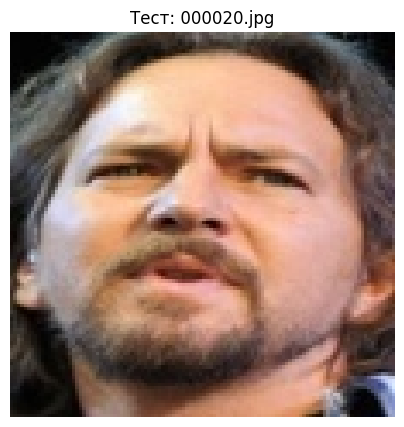

Heatmap не найден: Work_Dataset/000020.npy
Распаковываю в: /content/data
Найденные папки:
/content/data/Work_Dataset
/content/data/Heatmaps_Dataset


In [1]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/Face_Recognition_DLS/WorkDataset_and_Heatmap.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    all_files = zip_ref.namelist()

    # Фильтруем
    jpg_files = [f for f in all_files if f.endswith('.jpg')]
    npy_files = [f for f in all_files if f.endswith('.npy')]

    print(f"  Изображений (.jpg): {len(jpg_files)}")
    print(f"  Heatmaps (.npy): {len(npy_files)}")

    # Показываем структуру
    folders = set()
    for file in all_files[:30]:
        folder = os.path.dirname(file)
        if folder and folder not in folders:
            folders.add(folder)
            print(f"  {folder}/")


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # Находим первое изображение
    if jpg_files:
        test_jpg = jpg_files[0]
        print(f"Тестирую: {test_jpg}")

        # Читаем изображение прямо из архива
        import io
        from PIL import Image
        import matplotlib.pyplot as plt

        image_data = zip_ref.read(test_jpg)
        img = Image.open(io.BytesIO(image_data))

        print(f"   Размер: {img.size}")
        print(f"   Формат: {img.format}")

        # Показываем
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title(f"Тест: {os.path.basename(test_jpg)}")
        plt.axis('off')
        plt.show()

        # Теперь ищем heatmap
        test_npy = test_jpg.replace('.jpg', '.npy')
        if test_npy in npy_files:

            # Загружаем heatmap
            import numpy as np
            heatmap_data = zip_ref.read(test_npy)
            heatmap = np.load(io.BytesIO(heatmap_data))

            plt.figure(figsize=(12, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(img)
            plt.title("Изображение")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(heatmap[0], cmap='hot')
            plt.title("Heatmap (левый глаз)")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(img, alpha=0.7)
            plt.imshow(heatmap[0], cmap='hot', alpha=0.5)
            plt.title("Наложение")
            plt.axis('off')

            plt.suptitle("Тест архива")
            plt.tight_layout()
            plt.show()

        else:
            print(f"Heatmap не найден: {test_npy}")

        img.close()

extract_path = "/content/data"
print(f"Распаковываю в: {extract_path}")

# Удаляем старую папку если есть
!rm -rf {extract_path}

# Создаем новую
!mkdir -p {extract_path}

# Распаковываем
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Ищем папки
import subprocess

# Команда для поиска папок
result = subprocess.run(['find', extract_path, '-type', 'd', '-name', '*Work*', '-o', '-name', '*Heat*'],
                       capture_output=True, text=True)
folders = result.stdout.strip().split('\n')
folders = [f for f in folders if f]

print("Найденные папки:")
for folder in folders:
    print(f"{folder}")

    # Считаем файлы в папке
    if os.path.exists(folder):
        count_jpg = len([f for f in os.listdir(folder) if f.endswith('.jpg')])
        count_npy = len([f for f in os.listdir(folder) if f.endswith('.npy')])

def find_folder(pattern):
    result = subprocess.run(['find', extract_path, '-type', 'd', '-name', pattern],
                          capture_output=True, text=True)
    folders = result.stdout.strip().split('\n')
    return folders[0] if folders else None

work_dataset_path = find_folder('*Work*Dataset*')
if not work_dataset_path:
    result = subprocess.run(['find', extract_path, '-type', 'd', '-exec', 'sh', '-c',
                           'for d; do [ "$(find "$d" -maxdepth 1 -name "*.jpg" | head -1)" ] && echo "$d"; done',
                           '_', '{}', '+'], capture_output=True, text=True)
    work_dataset_path = result.stdout.strip().split('\n')[0] if result.stdout else None

heatmaps_path = find_folder('*Heat*Dataset*')
if not heatmaps_path:
    result = subprocess.run(['find', extract_path, '-type', 'd', '-exec', 'sh', '-c',
                           'for d; do [ "$(find "$d" -maxdepth 1 -name "*.npy" | head -1)" ] && echo "$d"; done',
                           '_', '{}', '+'], capture_output=True, text=True)
    heatmaps_path = result.stdout.strip().split('\n')[0] if result.stdout else None


Обучение модели

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from PIL import Image

# Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)

# Hourglass Module
class HourglassModule(nn.Module):
    def __init__(self, depth, channels):
        super().__init__()
        self.depth = depth
        self.channels = channels
        self.downsample = nn.MaxPool2d(2, 2)

        if depth > 1:
            self.hg = HourglassModule(depth - 1, channels)
            self.low_res = ResidualBlock(channels, channels)
        else:
            self.hg = ResidualBlock(channels, channels)

        self.res_before = ResidualBlock(channels, channels)
        self.res_after = ResidualBlock(channels, channels)

    def forward(self, x):
        skip = self.res_before(x)
        h, w = x.shape[2:]

        low = self.downsample(x)
        low = self.hg(low)
        up = F.interpolate(low, size=(h, w), mode='bilinear', align_corners=False)

        out = up + skip
        out = self.res_after(out)
        return out

# Heatmap Head
class HeatmapHead(nn.Module):
    def __init__(self, in_channels, num_keypoints):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(in_channels // 2)
        self.conv2 = nn.Conv2d(in_channels // 2, num_keypoints, 1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        return self.conv2(x)

class StackedHourglassNetwork(nn.Module):
    def __init__(self, num_stacks=2, num_blocks=3, in_channels=3, out_channels=5,
                 channels=128, input_size=112):
        super().__init__()
        self.num_stacks = num_stacks
        self.num_keypoints = out_channels
        self.channels = channels

        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, channels//4, 7, stride=1, padding=3),
            nn.BatchNorm2d(channels//4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            ResidualBlock(channels//4, channels//2),
            nn.MaxPool2d(2, 2),
            ResidualBlock(channels//2, channels)
        )

        self.hourglasses = nn.ModuleList([HourglassModule(num_blocks, channels) for _ in range(num_stacks)])
        self.heads = nn.ModuleList([HeatmapHead(channels, out_channels) for _ in range(num_stacks)])

        self.intermediate_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels, channels, 1),
                nn.BatchNorm2d(channels),
                nn.ReLU(inplace=True)
            ) for i in range(num_stacks-1)
        ])
        self.final_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, channels, 1),
                nn.BatchNorm2d(channels),
                nn.ReLU(inplace=True)
            ) for i in range(num_stacks-1)
        ])

    def forward(self, x):
        x = self.initial(x)
        outputs = []

        for i in range(self.num_stacks):
            hg_out = self.hourglasses[i](x)
            heatmap = self.heads[i](hg_out)
            outputs.append(heatmap)

            if i < self.num_stacks - 1:
                features = self.intermediate_convs[i](hg_out)
                heatmap_features = self.final_convs[i](heatmap)
                x = x + features + heatmap_features

        final_outputs = []
        for heatmap in outputs:
            final_heatmap = F.interpolate(heatmap, size=(112, 112), mode='bilinear', align_corners=False)
            final_outputs.append(final_heatmap)

        return final_outputs

class FaceKeypointsDataset(Dataset):
    def __init__(self, images_dir, heatmaps_dir, input_size=112):
        self.images_dir = images_dir
        self.heatmaps_dir = heatmaps_dir
        self.input_size = input_size
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.jpg')])
        print(f"Найдено {len(self.image_files)} изображений")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        try:
            img_filename = self.image_files[idx]
            img_path = os.path.join(self.images_dir, img_filename)

            img = Image.open(img_path).convert('RGB')
            image = np.array(img.resize((self.input_size, self.input_size)))
            img.close()

            base_name = os.path.splitext(img_filename)[0]
            hm_path = os.path.join(self.heatmaps_dir, base_name + '.npy')

            if os.path.exists(hm_path):
                heatmap = np.load(hm_path)
                if heatmap.shape[-2:] != (self.input_size, self.input_size):
                    heatmap = np.resize(heatmap, (5, self.input_size, self.input_size))
            else:
                heatmap = np.zeros((5, self.input_size, self.input_size))

            if len(image.shape) == 3 and image.shape[2] == 3:
                image = image.transpose(2, 0, 1)

            return torch.FloatTensor(image) / 255.0, torch.FloatTensor(heatmap)

        except:
            return (torch.zeros(3, self.input_size, self.input_size),
                   torch.zeros(5, self.input_size, self.input_size))

class HeatmapLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse_loss = nn.MSELoss()

    def forward(self, predictions, targets):
        total_loss = 0
        for pred in predictions:
            total_loss += self.mse_loss(pred, targets)
        return total_loss

def calculate_accuracy(predictions, targets, threshold=5.0):
    pred_heatmap = predictions[-1]
    batch_size, num_keypoints, H, W = pred_heatmap.shape
    pred_coords = torch.zeros(batch_size, num_keypoints, 2, device=pred_heatmap.device)
    target_coords = torch.zeros(batch_size, num_keypoints, 2, device=pred_heatmap.device)

    for i in range(batch_size):
        for j in range(num_keypoints):
            pred_idx = torch.argmax(pred_heatmap[i, j])
            pred_coords[i, j, 0] = pred_idx % W
            pred_coords[i, j, 1] = pred_idx // W

            target_idx = torch.argmax(targets[i, j])
            target_coords[i, j, 0] = target_idx % W
            target_coords[i, j, 1] = target_idx // W

    distances = torch.sqrt(torch.sum((pred_coords - target_coords) ** 2, dim=2))
    return (distances < threshold).float().mean().item()

# 7. Training
def train_model(model, train_loader, val_loader, num_epochs=30, lr=1e-3):
    model = model.to(device)

    sample_batch = next(iter(train_loader))
    sample_images = sample_batch[0].to(device)
    model.eval()
    with torch.no_grad():
        test_output = model(sample_images)
        print(f"Output shapes: {[o.shape for o in test_output]}")
        print(f"Target shape: {sample_batch[1].shape}")

    criterion = HeatmapLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0
        train_steps = 0

        for images, heatmaps in tqdm(train_loader, desc=f'Epoch {epoch+1} [Train]'):
            images, heatmaps = images.to(device), heatmaps.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, heatmaps)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()
            train_steps += 1

        avg_train_loss = train_loss / train_steps

        # Val
        model.eval()
        val_loss, val_acc, val_steps = 0, 0, 0

        with torch.no_grad():
            for images, heatmaps in tqdm(val_loader, desc=f'Epoch {epoch+1} [Val]'):
                images, heatmaps = images.to(device), heatmaps.to(device)
                outputs = model(images)
                loss = criterion(outputs, heatmaps)
                acc = calculate_accuracy(outputs, heatmaps)

                val_loss += loss.item()
                val_acc += acc
                val_steps += 1

        avg_val_loss = val_loss / val_steps
        avg_val_acc = val_acc / val_steps

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_hourglass_model.pth')

        scheduler.step(avg_val_loss)
        print(f"Epoch {epoch+1}: Train {avg_train_loss:.4f}, Val {avg_val_loss:.4f}, Acc {avg_val_acc:.3f}")

    return model

def main():
    images_dir = '/content/data/Work_Dataset'
    heatmaps_dir = '/content/data/Heatmaps_Dataset'

    dataset = FaceKeypointsDataset(images_dir, heatmaps_dir)

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

    model = StackedHourglassNetwork(num_stacks=2, channels=128, input_size=112)
    print(f"Model: {sum(p.numel() for p in model.parameters()):,} params")

    trained_model = train_model(model, train_loader, val_loader, num_epochs=10)
if __name__ == "__main__":
    main()


Using device: cuda
Найдено 14959 изображений
Model: 1,085,322 params
Output shapes: [torch.Size([8, 5, 112, 112]), torch.Size([8, 5, 112, 112])]
Target shape: torch.Size([8, 5, 112, 112])


Epoch 1 [Val]: 100%|██████████| 374/374 [00:12<00:00, 31.00it/s]


Epoch 1: Train 0.0023, Val 0.0006, Acc 0.964


Epoch 2 [Val]: 100%|██████████| 374/374 [00:11<00:00, 32.40it/s]


Epoch 2: Train 0.0005, Val 0.0005, Acc 0.975


...

Epoch 8: Train 0.0003, Val 0.0004, Acc 0.988


Epoch 9 [Val]: 100%|██████████| 374/374 [00:11<00:00, 31.57it/s]


Epoch 9: Train 0.0003, Val 0.0004, Acc 0.989


Epoch 10 [Val]: 100%|██████████| 374/374 [00:11<00:00, 32.29it/s]


Epoch 10: Train 0.0003, Val 0.0004, Acc 0.989


Отличный результат, чтобы в этом убедиться посмотрим визуализацию

Визуализация

Найдено 14959 изображений


/tmp/ipython-input-616845025.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1,1))


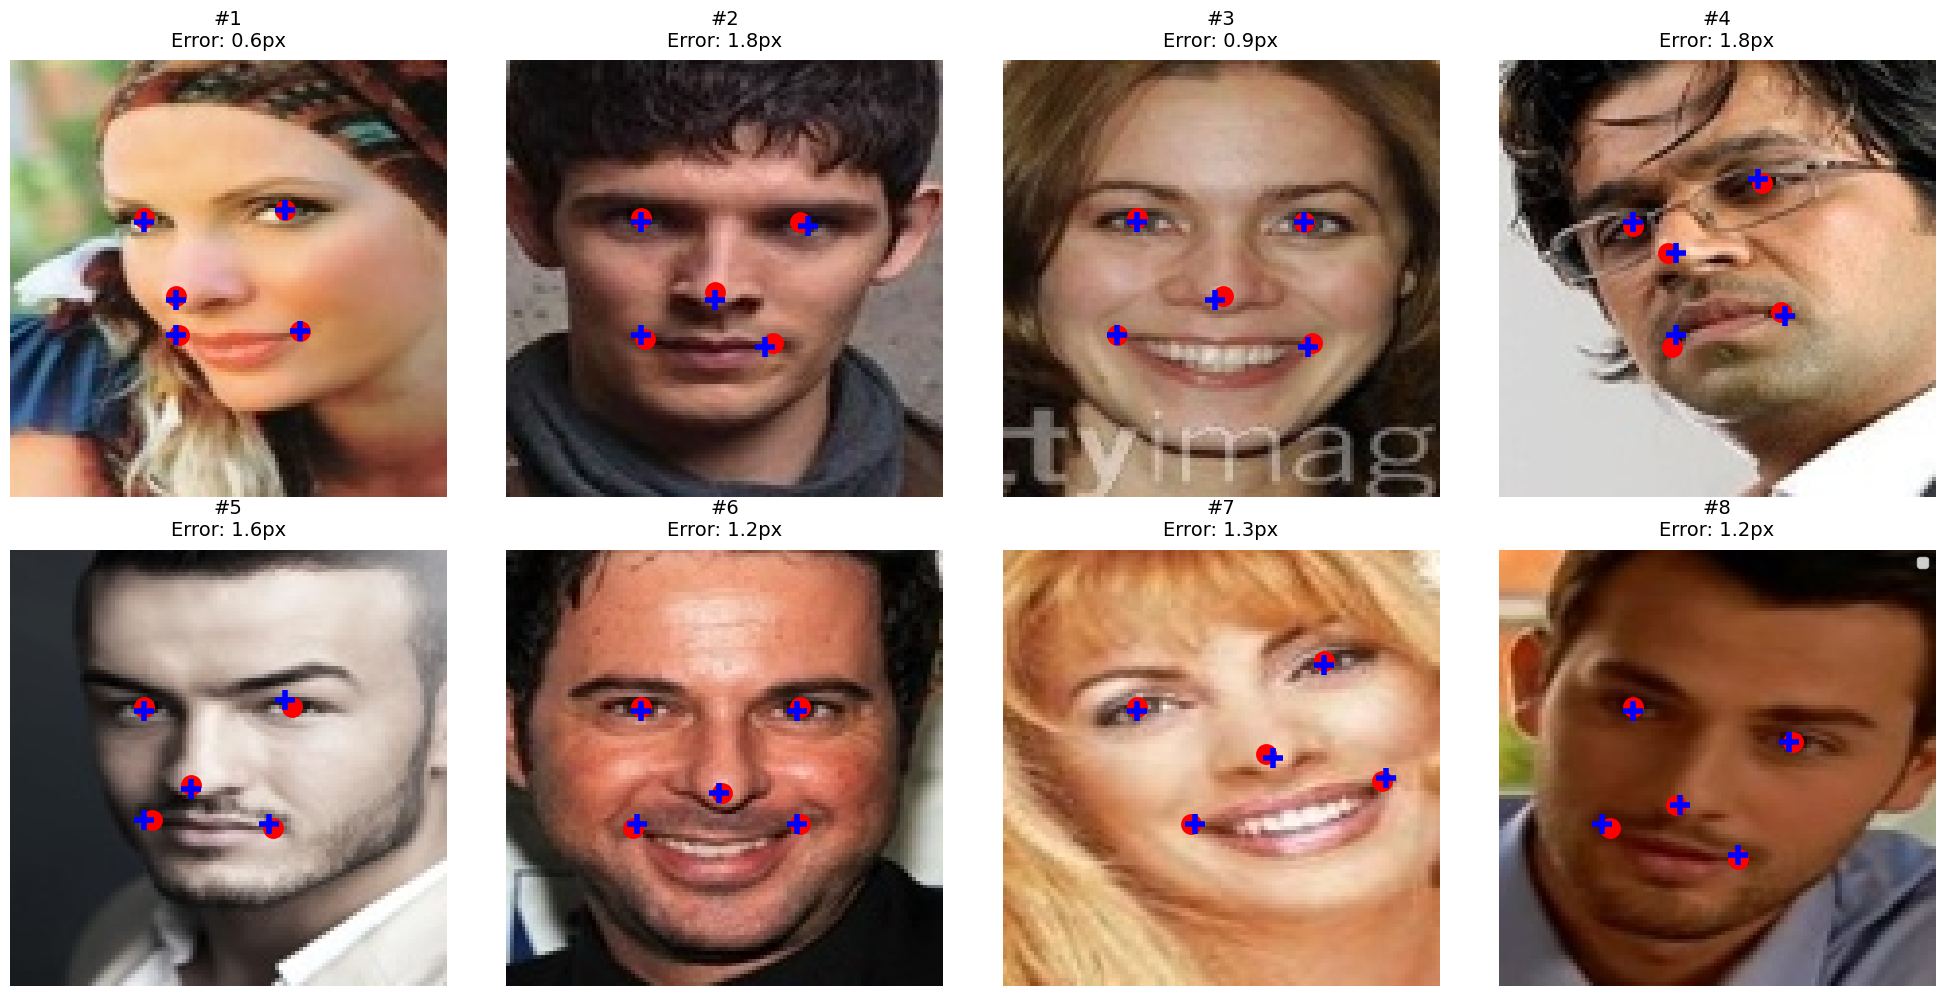

Средняя ошибка: 1.31 пикселей


In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = StackedHourglassNetwork(num_stacks=2, channels=128, input_size=112)
model.load_state_dict(torch.load('best_hourglass_model.pth', map_location=device))
model.to(device).eval()

dataset = FaceKeypointsDataset('/content/data/Work_Dataset', '/content/data/Heatmaps_Dataset')
val_loader = DataLoader(dataset, batch_size=8, shuffle=True)

def visualize_final_results(model, dataloader, num_samples=8):
    model.eval()
    samples = []

    with torch.no_grad():
        for images, heatmaps in dataloader:
            images = images.to(device)
            predictions = model(images)
            pred_heatmaps = predictions[-1].cpu()

            for i in range(min(num_samples, images.size(0))):
                img = images[i].cpu().permute(1, 2, 0).numpy()
                gt_hm = heatmaps[i].numpy()
                pred_hm = pred_heatmaps[i].numpy()

                # Координаты 5 точек
                pred_coords, gt_coords = [], []
                for k in range(5):
                    pred_y, pred_x = np.unravel_index(np.argmax(pred_hm[k]), (112, 112))
                    gt_y, gt_x = np.unravel_index(np.argmax(gt_hm[k]), (112, 112))
                    pred_coords.append((int(pred_x), int(pred_y)))
                    gt_coords.append((int(gt_x), int(gt_y)))

                samples.append((img, gt_coords, pred_coords))
                if len(samples) >= num_samples:
                    break

            if len(samples) >= num_samples:
                break

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()

    total_error = 0
    for i, (img, gt_coords, pred_coords) in enumerate(samples):
        ax = axes[i]

        ax.imshow(img)

        for x, y in gt_coords:
            ax.plot(x, y, 'ro', markersize=12, markeredgecolor='red',
                   markeredgewidth=3, label='GT' if i==0 else "")

        for x, y in pred_coords:
            ax.plot(x, y, 'b+', markersize=15, markeredgewidth=4,
                   markeredgecolor='blue', label='Pred' if i==0 else "")

        error = 0
        for j in range(5):
            dx = gt_coords[j][0] - pred_coords[j][0]
            dy = gt_coords[j][1] - pred_coords[j][1]
            error += np.sqrt(dx*dx + dy*dy)
        total_error += error / 5

        ax.set_title(f'#{i+1}\nError: {error/5:.1f}px', fontsize=14, pad=10)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('final_predictions.png', dpi=300, bbox_inches='tight')
    plt.legend(loc='upper right', bbox_to_anchor=(1,1))
    plt.show()

    avg_error = total_error / len(samples)
    print(f"Средняя ошибка: {avg_error:.2f} пикселей")


    return avg_error

avg_error = visualize_final_results(model, val_loader)


Получилось очень даже хорошо, ошибки минимальны, обучение прошло хорошо. Жаль выравнивание не оч

Выравнивание лиц


Найдено 14959 изображений


/tmp/ipython-input-2579031643.py:106: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2579031643.py:107: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('face_alignment_PERFECT.png', dpi=300, bbox_inches='tight')


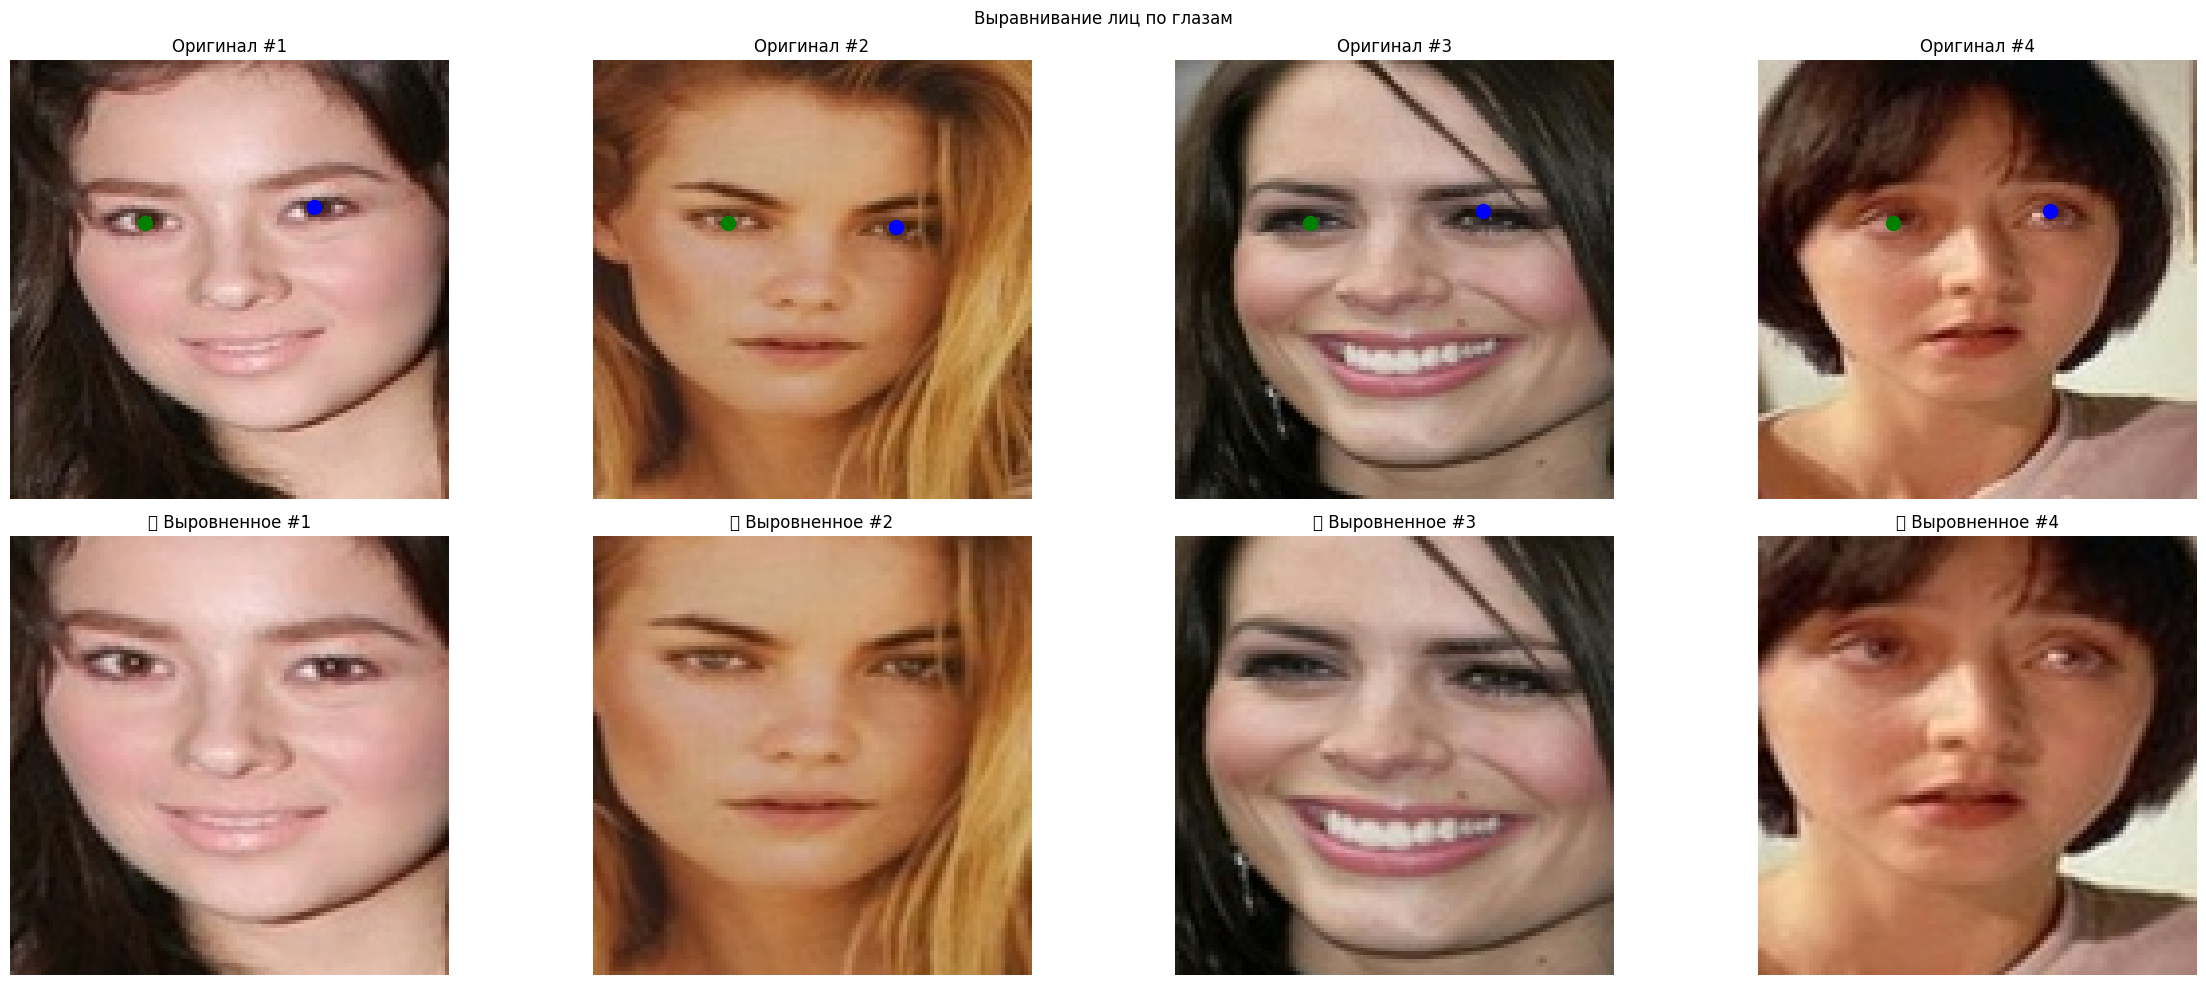

In [26]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = StackedHourglassNetwork(num_stacks=2, channels=128, input_size=112)
model.load_state_dict(torch.load('best_hourglass_model.pth', map_location=device))
model.to(device).eval()

dataset = FaceKeypointsDataset('/content/data/Work_Dataset', '/content/data/Heatmaps_Dataset')
val_loader = DataLoader(dataset, batch_size=8, shuffle=True)

def get_keypoints_from_heatmaps(heatmaps):
    batch_size, num_keypoints, H, W = heatmaps.shape
    coords = torch.zeros(batch_size, num_keypoints, 2)
    for b in range(batch_size):
        for k in range(num_keypoints):
            idx = torch.argmax(heatmaps[b, k])
            y = idx // W
            x = idx % W
            coords[b, k, 0] = x
            coords[b, k, 1] = y
    return coords.float()

def align_face(image_rgb, keypoints, output_size=(112, 112)):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

    # Определяем левый/правый глаз по X
    eye1, eye2 = keypoints[0], keypoints[1]
    if eye1[0] > eye2[0]:
        left_eye, right_eye = eye2, eye1
    else:
        left_eye, right_eye = eye1, eye2

    # Вычисляем угол поворота
    dY = right_eye[1] - left_eye[1]
    dX = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dY, dX))

    center = (left_eye + right_eye) * 0.5

    # Масштаб
    eye_distance = np.linalg.norm(right_eye - left_eye)
    desired_distance = 0.45 * output_size[0]
    scale = desired_distance / eye_distance

    # Матрица поворота
    M = cv2.getRotationMatrix2D(tuple(center), angle, scale)

    # Центрируем по вертикали
    target_y = output_size[1] * 0.35
    eyes_center_y = center[1]
    M[1, 2] += target_y - eyes_center_y * scale

    aligned_bgr = cv2.warpAffine(image_bgr, M, output_size,
                                 flags=cv2.INTER_LANCZOS4,
                                 borderMode=cv2.BORDER_REFLECT_101)
    aligned_rgb = cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2RGB)

    return aligned_rgb, M, (left_eye, right_eye)

def visualize_alignment(model, dataloader, num_samples=4):
    model.eval()
    samples = []

    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(dataloader):
            images_t = images.to(device)
            predictions = model(images_t)
            pred_heatmaps = predictions[-1].cpu()
            pred_coords = get_keypoints_from_heatmaps(pred_heatmaps)

            images_np = (images * 255).byte().permute(0, 2, 3, 1).numpy()

            for i in range(min(num_samples, len(images))):
                orig_rgb = images_np[i]
                keypoints = pred_coords[i].numpy()

                aligned, M, eyes = align_face(orig_rgb, keypoints)
                samples.append((orig_rgb, aligned, keypoints, eyes))

                if len(samples) >= num_samples:
                    break
            if len(samples) >= num_samples:
                break

    fig, axes = plt.subplots(2, num_samples, figsize=(6*num_samples, 10))
    if num_samples == 1:
        axes = axes.reshape(2,1)

    for i, (orig, aligned, keypoints, eyes) in enumerate(samples):
        axes[0,i].imshow(orig)
        axes[0,i].plot(keypoints[0,0], keypoints[0,1], 'go', markersize=10, label='Левый глаз')
        axes[0,i].plot(keypoints[1,0], keypoints[1,1], 'bo', markersize=10, label='Правый глаз')
        axes[0,i].set_title(f'Оригинал #{i+1}')
        axes[0,i].axis('off')

        axes[1,i].imshow(aligned)
        axes[1,i].set_title(f'✅ Выровненное #{i+1}')
        axes[1,i].axis('off')

    plt.suptitle('Выравнивание лиц по глазам')
    plt.tight_layout()
    plt.savefig('face_alignment_PERFECT.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_alignment(model, val_loader)


Просмотрел, что получается на сложных случаях и могу сказать, что не хватает нелинейных преобразований, возможно нужно было использовать не только афинное преобразование, но и добавить к нему решения, которые решали бы проблему сильного поворота лица, но простые случаи делает неплохо.
